In [2]:
# defining root location of the project on local system (change this to your own path after pulling)
import numpy as np 
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb

# set up plotting config
mpl.rcParams['mathtext.fontset'] = 'stix'  # or 'dejavusans', 'cm', 'custom'
mpl.rcParams['font.family'] = 'STIXGeneral'  # Matches STIX math font
# set tick font size
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
# set default fontsize
mpl.rcParams['font.size'] = 16

# define root
ROOT = "/home/andreasstillits/coding/Leaves1D/"
%pwd

'/home/andreasstillits/coding/Leaves1D/figures/scripts'

### Helper functions

In [3]:
def map_data_values(df: pd.DataFrame, map: np.ndarray, vmin: float = 0.01, vmax: float = 100) -> np.ndarray:
    taus_data = df['tau'].to_numpy()
    gammas_data = df['gamma'].to_numpy()
    N_gamma, N_tau = map.shape 
    taus = np.exp(np.linspace(np.log(vmin), np.log(vmax), N_tau))
    gammas = np.exp(np.linspace(np.log(vmin), np.log(vmax), N_gamma))
    log_taus = np.log(taus)
    log_gammas = np.log(gammas)
    
    values = []
    for tau_data, gamma_data in zip(taus_data, gammas_data):
        # Handle out-of-bounds values by clipping to grid range via nearest neighbour
        if (tau_data <= taus[0]) or (tau_data >= taus[-1]) or (gamma_data <= gammas[0]) or (gamma_data >= gammas[-1]):
            idx_tau = int(np.argmin(np.abs(taus - tau_data)))
            idx_gamma = int(np.argmin(np.abs(gammas - gamma_data)))
            values.append(map[idx_gamma, idx_tau])
            continue

        # Work in log-space for interpolation weights
        log_tau_data = np.log(tau_data)
        log_gamma_data = np.log(gamma_data)

        # Find indices of the two neighbouring grid points in each direction (in log-space)
        idx_tau_upper = int(np.searchsorted(log_taus, log_tau_data, side="right"))
        idx_tau_lower = idx_tau_upper - 1
        idx_gamma_upper = int(np.searchsorted(log_gammas, log_gamma_data, side="right"))
        idx_gamma_lower = idx_gamma_upper - 1

        x0, x1 = log_taus[idx_tau_lower], log_taus[idx_tau_upper]
        y0, y1 = log_gammas[idx_gamma_lower], log_gammas[idx_gamma_upper]

        f00 = map[idx_gamma_lower, idx_tau_lower]
        f10 = map[idx_gamma_lower, idx_tau_upper]
        f01 = map[idx_gamma_upper, idx_tau_lower]
        f11 = map[idx_gamma_upper, idx_tau_upper]

        tx = (log_tau_data - x0) / (x1 - x0)
        ty = (log_gamma_data - y0) / (y1 - y0)

        value = (
            (1 - tx) * (1 - ty) * f00 +
            tx * (1 - ty) * f10 +
            (1 - tx) * ty * f01 +
            tx * ty * f11
)
        values.append(value)

    return np.array(values)
    
def std_layout(ax: plt.Axes, color: str = "dimgrey", vmin: float = 0.01, vmax: float = 100, inset: bool = False) -> None:
    """Helper function to set standard plot settings for (tau,gamma) figures."""
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)
    ax.plot([1, 1], [vmin, vmax], color="grey", linestyle="-.", zorder=2)
    ax.plot([vmin, vmax], [1, 1], color="grey", linestyle="-.", zorder=2)

    df = pd.read_csv(ROOT + "data/saved_data/Knauer2022_hypostomatous.csv", decimal=',', sep=';')
    dfMomayyeziW = pd.read_csv(ROOT + 'data/saved_data/Momayyezi2022_watered.csv', sep=';', decimal=',')
    dfMomayyeziDH = pd.read_csv(ROOT + 'data/saved_data/Momayyezi2022_dehydrated.csv', sep=';', decimal=',')

    markersize = 35 if not inset else 10

    ax.scatter(df['tau'], df['gamma'], color=color, marker="o", zorder=3, label="Knauer et al.", s=markersize)
    ax.scatter(dfMomayyeziW['tau'], dfMomayyeziW['gamma'], color=color, marker="o", zorder=3, label="Momayyezi et al. (watered)", s=markersize)
    ax.scatter(dfMomayyeziDH['tau'], dfMomayyeziDH['gamma'], color=color, marker="o", zorder=3, label="Momayyezi et al. (dehydrated)", s=markersize)
    if not inset:
        ax.set_xlabel(r"Absorption balance $\tau$ []")
        ax.set_ylabel(r"Transport balance $\gamma$ []")
        # ax.legend(loc="upper left", fontsize=10)            

def std_histogram(ax: plt.Axes, xlabel: str = "Error (%)") -> None:
    ax.set_ylabel('Count')
    ax.set_xlabel(xlabel)
    ax.set_yscale('log')
    ax.legend(loc="upper right", fontsize=10)
    return

def describe_errors(errors: np.ndarray, *thresholds: float) -> None:
    print(f"Mean error: {np.mean(errors):.2f}%")
    print(f"Median error: {np.median(errors):.2f}%")
    print(f"Max error: {np.max(errors):.2f}%")
    print(f"Min error: {np.min(errors):.2f}%")
    for threshold in thresholds:
        print(f"Percentage of errors below {threshold}%: {100 * np.sum(errors < threshold)/len(errors):.2f}%")
    print("\n")

### Figure 4 - discrete decision map

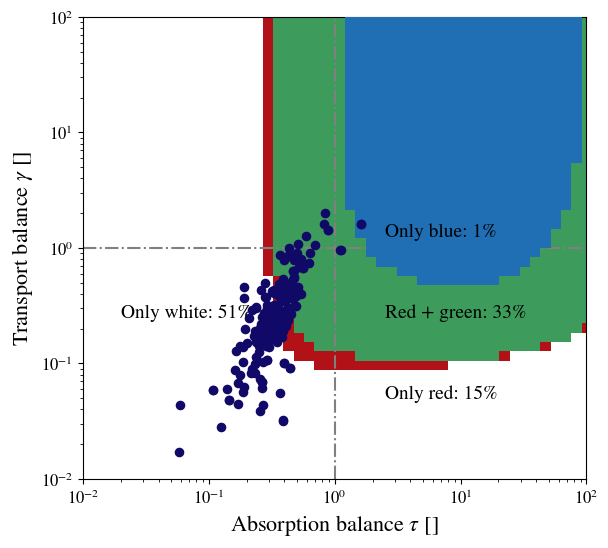

In [5]:
def transform_heatmap(map: np.ndarray, vmin: float = 5) -> np.ndarray:
    mask = map < vmin
    transformed_map = map.copy()
    transformed_map[mask] = 0
    transformed_map[~mask] = 1
    return transformed_map

def colormap(name: str):
    colors = [[1, 1, 1, 0], to_rgb(name) + (1,)]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([0, 1], cmap.N)
    return cmap, norm

def plot(ax: plt.Axes, map: np.ndarray, cmap: ListedColormap, norm: BoundaryNorm, zorder: int) -> None:
    N = map.shape[0]
    taus = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    gammas = np.exp(np.linspace(np.log(0.01), np.log(100), N))
    ax.pcolormesh(taus, gammas, map, cmap=cmap, norm=norm, shading='auto', zorder=zorder)


vmin = 10

# load heatmap data
gradients = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/gradients/3Dv0D_typical.txt", delimiter=";").T   # 3D vs 0D
gradients = transform_heatmap(gradients, vmin=vmin)

lateral = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/lateral/3Dv1D_typical.txt", delimiter=";").T   # 3D vs 1D
lateral = transform_heatmap(lateral, vmin=vmin)

hetero = 100 * np.loadtxt(ROOT + "data/saved_data/heatmaps/heterogeneity/3D_typical_contrast_0.20.txt", delimiter=";").T
hetero = transform_heatmap(hetero, vmin=vmin)

# plotting
fig, ax = plt.subplots(figsize=(6.5, 6))
    
cmap_red, norm = colormap("#b21117ff")  # "#a71413ff"
cmap_green, _ = colormap("#3d9c5bff")   # "#16440fff"
cmap_blue, _ = colormap("#206eb3ff")   # "#130a5eff"

plot(ax, gradients, cmap_red, norm, zorder=1)
plot(ax, lateral, cmap_green, norm, zorder=2)
plot(ax, hetero, cmap_blue, norm, zorder=3)

# ax.set_title(f"Decision boundaries at {vmin:.0f}% (All 3D typical!)")
ax.text(0.02, 0.05*5, "Only white: 51%", color="black", fontsize=14)
ax.text(2.5, 0.05, "Only red: 15%", color="black", fontsize=14)
ax.text(2.5, 0.05*5, "Red + green: 33%", color="black", fontsize=14)
ax.text(2.5, 0.05*5*5, "Only blue: 1%", color="black", fontsize=14)

std_layout(ax, color=to_rgb("#110967ff"))
plt.savefig(ROOT + "figures/vectorgraphics/figure4/figure4.svg")
plt.savefig(ROOT + "figures/vectorgraphics/figure4/figure4.png", dpi=300)
plt.show()